In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

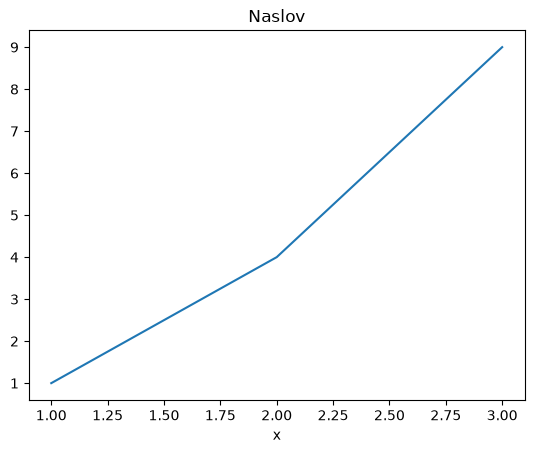

In [3]:
fig, ax = plt.subplots()

ax.plot([1, 2, 3], [1, 4, 9])
ax.set_title("Naslov")
ax.set_xlabel("x")

plt.show()

In [4]:
tips = sns.load_dataset("tips")
penguins = sns.load_dataset("penguins")
titanic = sns.load_dataset("titanic")

### Koristimo ax umesto plt za komande da bismo odmah birali za koji radimo e ako radimo samo 1 onda moze plt i onda su funckije bez set_
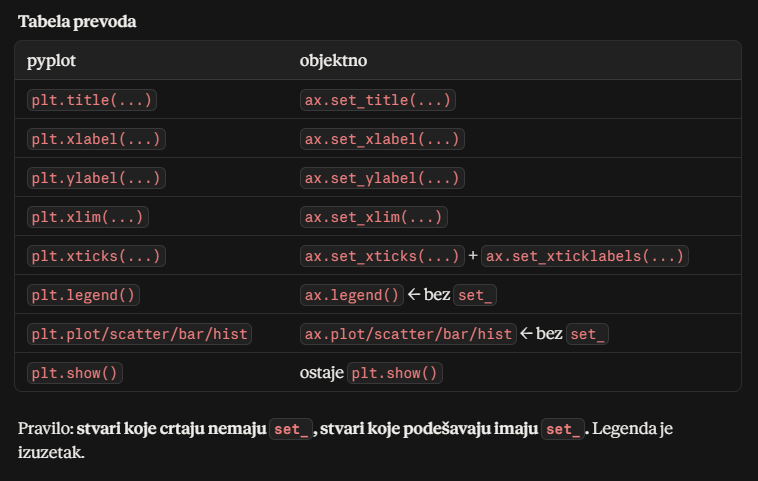
- set title naravno podesava naslov i to je intuitivno kao ostalo
- figsize je velicina celog platna znaci svi crtezi zajedno
- parametri 2,2 u subplots su koliko slicica tj axes-a imamo na tom nasem platnu u ovom slucaju 2x2

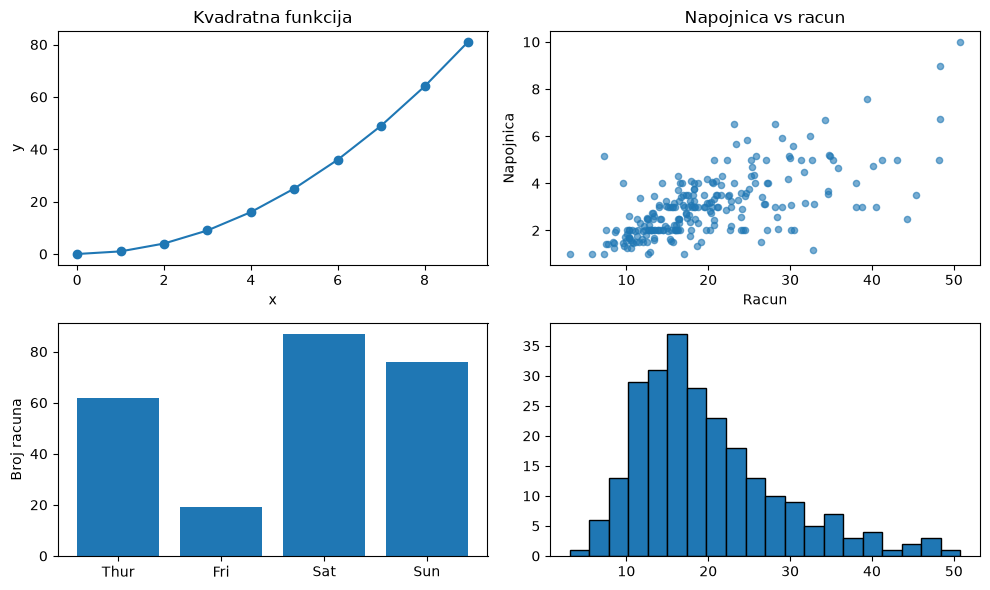

In [5]:
x = np.arange(0, 10)
y = x ** 2

fig, ax = plt.subplots(2,2, figsize=(10, 6))
ax[0,0].plot(x, y, marker="o")
ax[0,0].set_title("Kvadratna funkcija")
ax[0,0].set_xlabel("x")
ax[0,0].set_ylabel("y")
#plt.show() ocigledno nece da radi kad se 2 puta pozove show samo se prvi prikaze poziv
ax[0,1].scatter(tips["total_bill"], tips["tip"], s = 20, alpha = 0.6)
#s je velicina tacke a alpha providnost kad se ovako preklapaju tacke
ax[0,1].set(xlabel = "Racun", ylabel = "Napojnica", title = "Napojnica vs racun")
#moze i ovako sve u jedan set da se smesti
brojevi = tips["day"].value_counts().sort_index()
#print(brojevi)
ax[1,0].bar(brojevi.index.astype(str), brojevi.values)
ax[1,0].set(ylabel = "Broj racuna")
ax[1,1].hist(tips["total_bill"], bins = 20, edgecolor = "black")
plt.tight_layout()
plt.show()

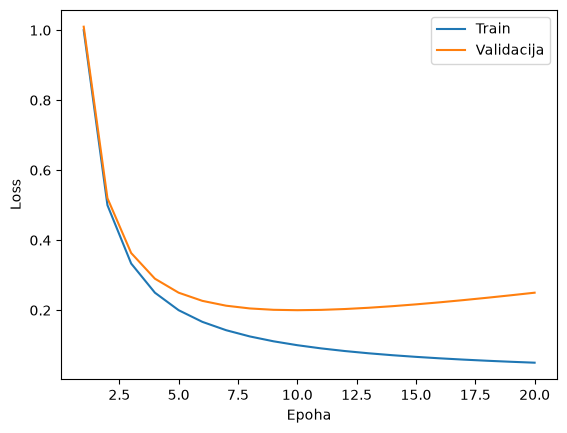

In [6]:
epoha = np.arange(1, 21)
train = 1.0 / epoha
val = 1.0 / epoha + 0.01 * epoha

fig, ax = plt.subplots()
ax.plot(epoha, train, label = "Train")
ax.plot(epoha, val, label = "Validacija")
ax.set(xlabel = "Epoha", ylabel = "Loss")
ax.legend()
plt.show()

### Nivo 1

array([8., 4.])

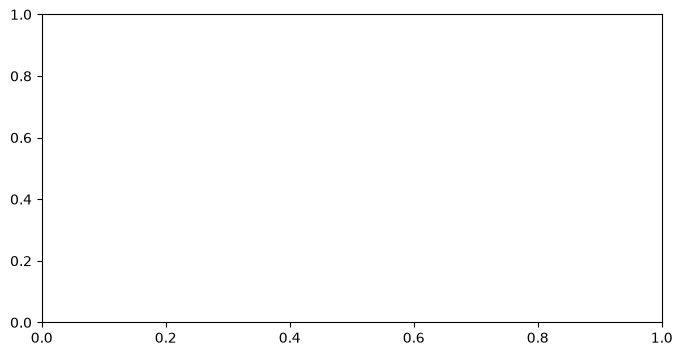

In [9]:
fig, ax = plt.subplots(figsize = (8,4))
fig.get_size_inches()

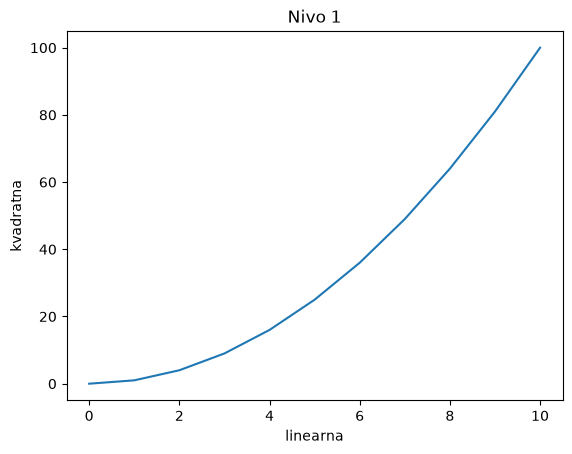

In [14]:
x = np.linspace(0, 10, 11)
#print(x)
y = x ** 2
fig, ax = plt.subplots()
ax.plot(x, y)
ax.set(title = "Nivo 1", xlabel = "linearna", ylabel = "kvadratna")
plt.show()

### Nivo 2


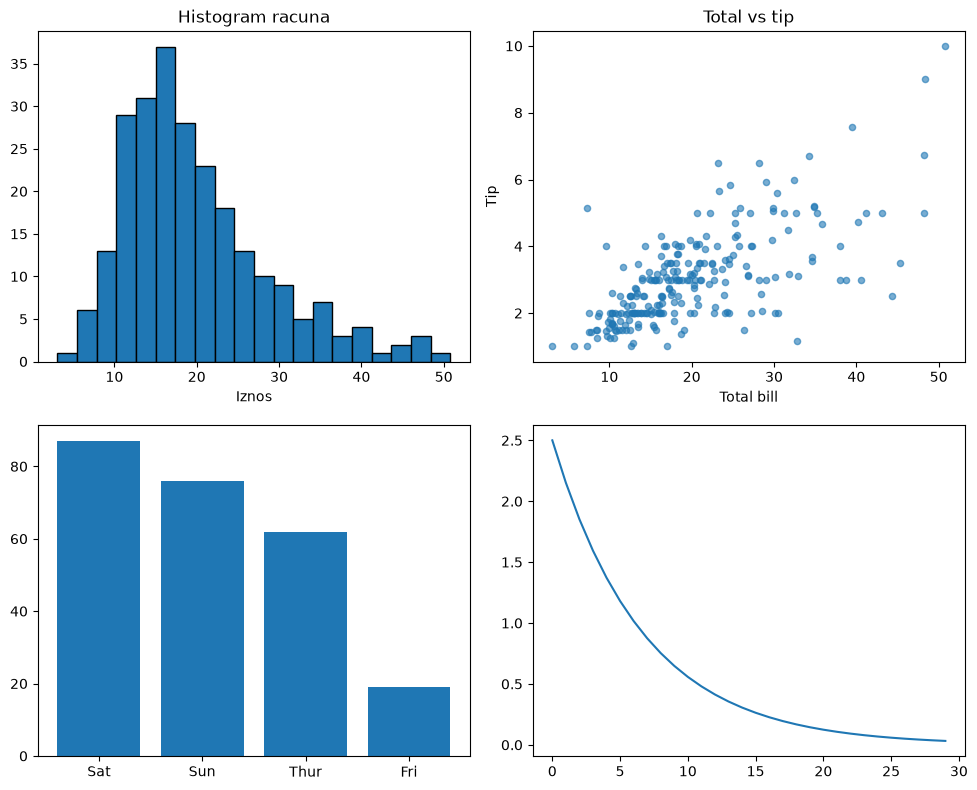

In [37]:
fig, ax = plt.subplots(2,2, figsize = (10,8))
ax[0,0].hist(tips["total_bill"], bins = 20, edgecolor = "black")
ax[0,0].set(xlabel = "Iznos", title = "Histogram racuna")

ax[0,1].scatter(tips["total_bill"], tips["tip"], alpha = 0.6, s = 20)
ax[0,1].set(title = "Total vs tip", xlabel = "Total bill", ylabel = "Tip")
plt.tight_layout()
#print(tips.iloc[[tips["tip"].idxmax()]])

#print(tips["day"].values)
#print(tips["day"].value_counts())
ax[1,0].bar(tips["day"].value_counts().index.astype(str), tips["day"].value_counts())

epoha = np.arange(30)
loss = 2.5 * np.exp(-0.15 * epoha)
ax[1,1].plot(epoha, loss)

plt.show()

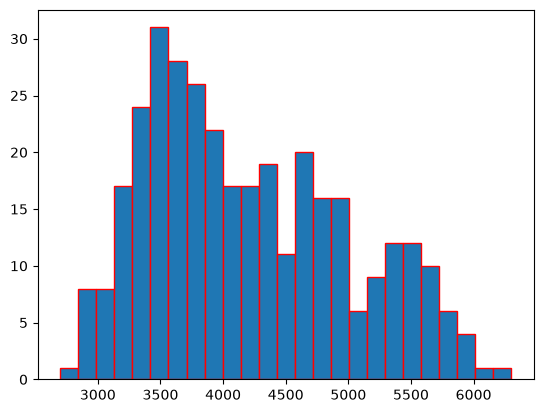

In [39]:
plt.hist(penguins["body_mass_g"], bins = 25, edgecolor = "red")
plt.show()

### Nivo 3

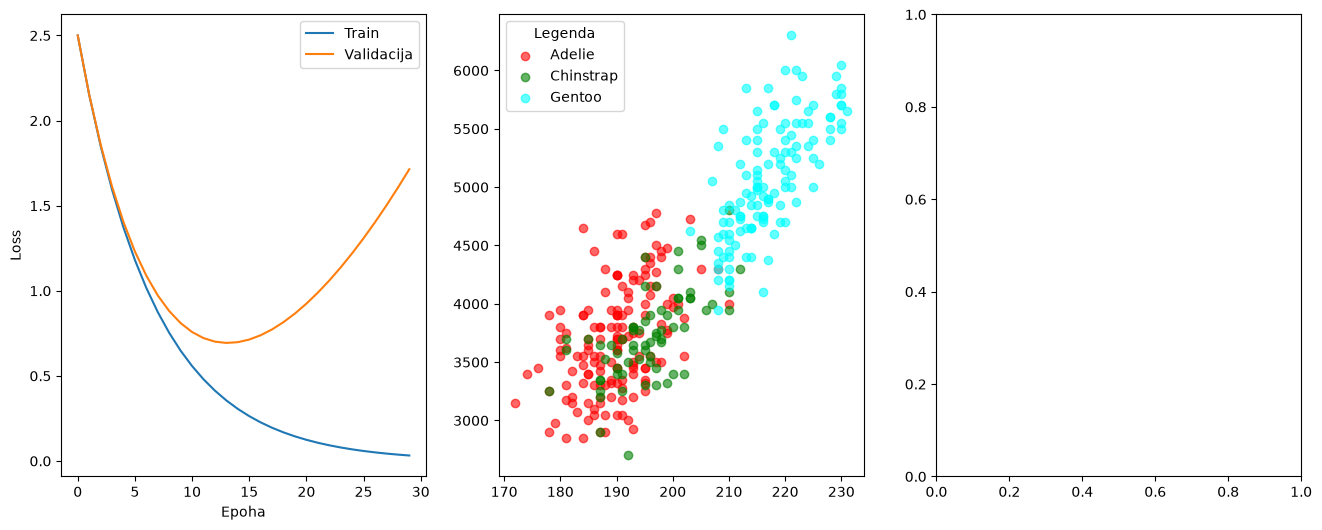

In [60]:
train = 2.5 * np.exp(-0.15 * epoha) 
val = train + 0.002 * epoha ** 2
fig, ax = plt.subplots(1,3, figsize = (16,6))
ax[0].plot(epoha, train, label = "Train")
ax[0].plot(epoha, val, label = "Validacija")
ax[0].set(xlabel = "Epoha", ylabel = "Loss")
ax[0].legend()

ax[1].scatter((penguins[penguins["species"] == "Adelie"])["flipper_length_mm"],(penguins[penguins["species"] == "Adelie"])["body_mass_g"], alpha = 0.6, color = "red", label = "Adelie")
ax[1].scatter((penguins[penguins["species"] == "Chinstrap"])["flipper_length_mm"],(penguins[penguins["species"] == "Chinstrap"])["body_mass_g"], alpha = 0.6, color = "green", label = "Chinstrap")
ax[1].scatter((penguins[penguins["species"] == "Gentoo"])["flipper_length_mm"],(penguins[penguins["species"] == "Gentoo"])["body_mass_g"], alpha = 0.6, color = "cyan", label = "Gentoo")
ax[1].legend(title = "Legenda", loc = "upper left")
plt.show()

In [55]:
print((penguins.groupby("species"))["body_mass_g"].mean())

species
Adelie       3700.662252
Chinstrap    3733.088235
Gentoo       5076.016260
Name: body_mass_g, dtype: float64


smoker  Yes  No
day            
Thur     17  45
Fri      15   4
Sat      42  45
Sun      19  57


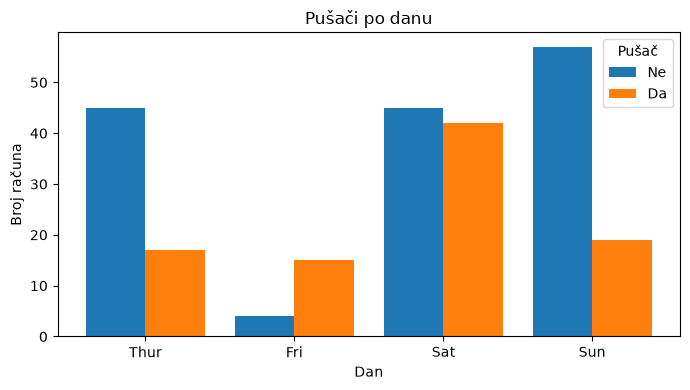

In [61]:
# prebrojavanje: koliko pušača i nepušača po danu
podaci = tips.groupby("day")["smoker"].value_counts().unstack()
print(podaci)

x = np.arange(4)          # pozicije: 0, 1, 2, 3 - po jedna za svaki dan
sirina = 0.4              # širina jednog stubića

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(x - sirina/2, podaci["No"],  width=sirina, label="Ne")
ax.bar(x + sirina/2, podaci["Yes"], width=sirina, label="Da")

ax.set_xticks(x)
ax.set_xticklabels(podaci.index)

ax.set(xlabel="Dan", ylabel="Broj računa", title="Pušači po danu")
ax.legend(title="Pušač")

fig.tight_layout()
plt.show()

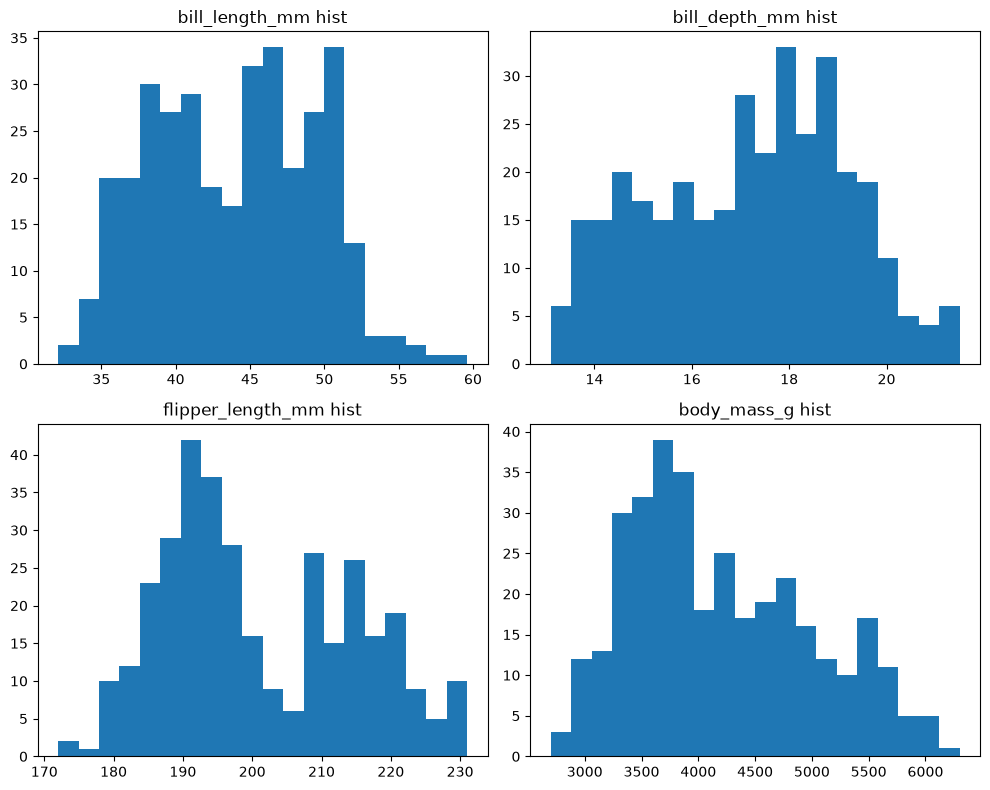

In [70]:
numericke = penguins.select_dtypes(include = "number")

fig, axes = plt.subplots(2, 2, figsize = (10, 8))
#print(axes.ravel())
for ax, kolona in zip(axes.ravel(), numericke.columns):
    ax.hist(penguins[kolona], bins = 20)
    ax.set_title(kolona + " hist")
plt.tight_layout()
plt.show()

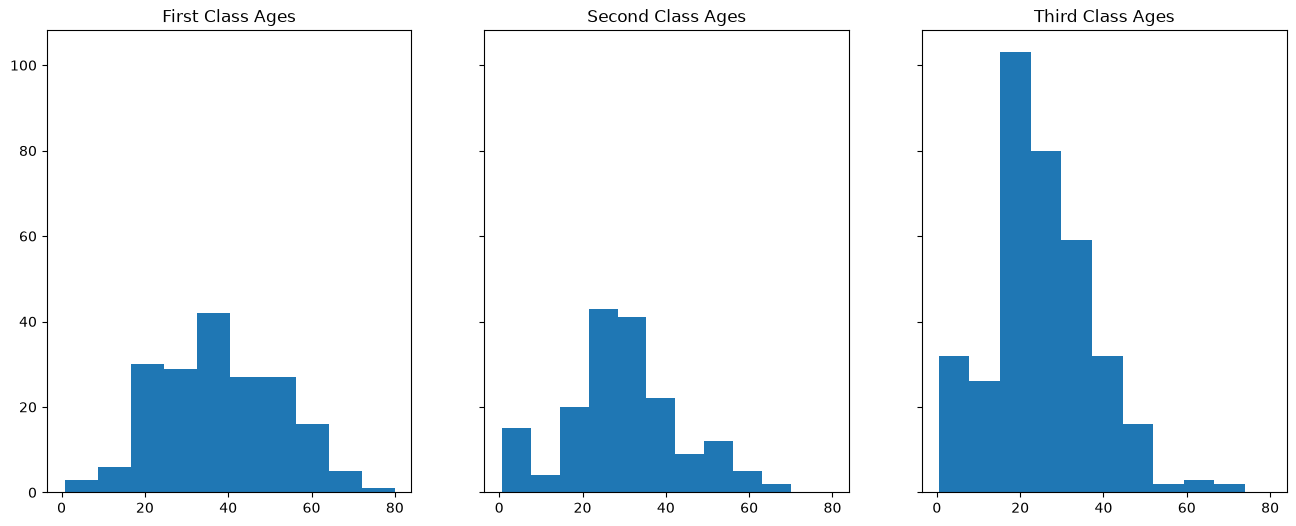

In [76]:
#print(titanic)
fig, ax = plt.subplots(1, 3, figsize = (16,6), sharex = True, sharey = True)
god = titanic["age"]
ax[0].hist(god[titanic["class"] == "First"])
ax[0].set_title("First Class Ages")
ax[1].hist(god[titanic["class"] == "Second"])
ax[1].set_title("Second Class Ages")
ax[2].hist(god[titanic["class"] == "Third"])
ax[2].set_title("Third Class Ages")
plt.show()

### Nivo 5

age            177
embarked         2
deck           688
embark_town      2
dtype: int64


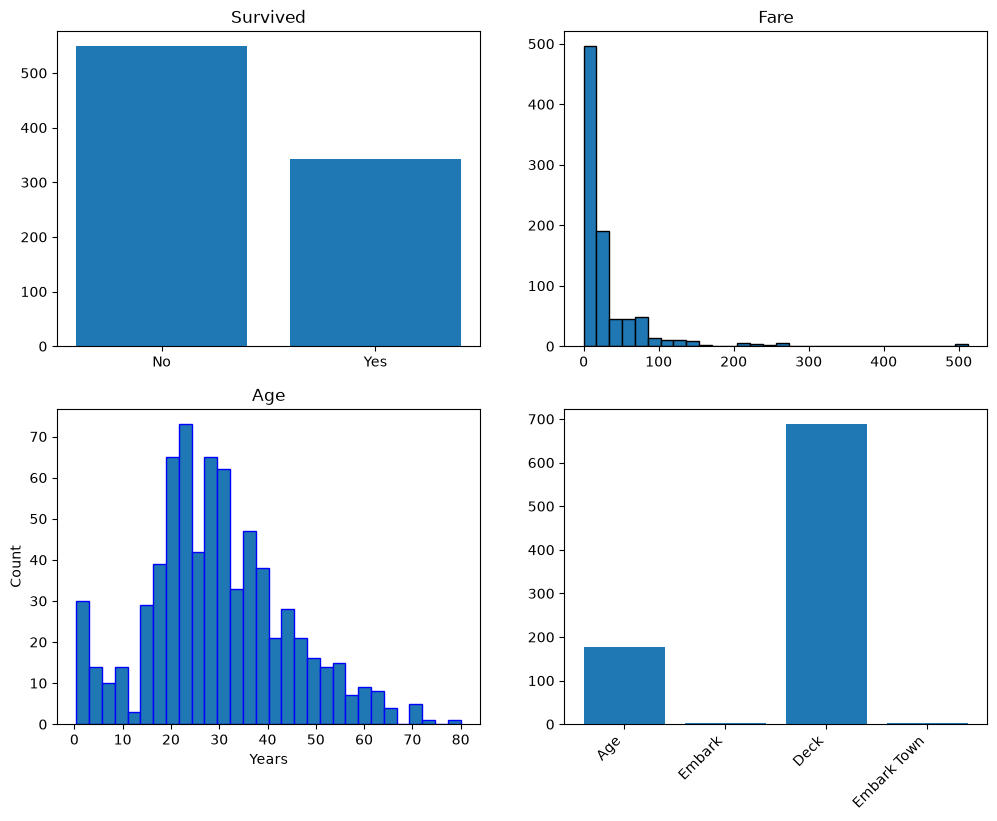

In [108]:
fig, ax = plt.subplots(2, 2, figsize = (12, 9))
prez = titanic["survived"].value_counts()
x = np.arange(2)
#print(prez)
#neprez = titanic[titanic["survived"] == 0]
ax[0,0].bar(x, prez.values)
ax[0,0].set_xticks(x)
ax[0,0].set_xticklabels(["No", "Yes"])
ax[0,0].set_title("Survived")

#print(titanic["fare"])
ax[0,1].hist(titanic["fare"], bins = 30, edgecolor = "black")
ax[0,1].set(title = "Fare")

ax[1,0].hist(titanic["age"], bins = 30, edgecolor = "blue")
ax[1,0].set(title = "Age", xlabel = "Years", ylabel = "Count")


nan = titanic.isnull().sum()
dat = nan[nan > 0]
print(dat)
ax[1,1].bar(dat.index, dat.values)
ax[1,1].set_xticks(np.arange(len(dat)))
ax[1,1].set_xticklabels(["Age", "Embark", "Deck", "Embark Town"], ha = "right", rotation = 45)
plt.show()
